# Chapter 2: Customer Support Triage

Every support operation faces the same problem: an incoming ticket needs to reach the right team at the right priority and it needs to happen fast. Get it wrong and a critical outage sits in the general queue while a low-priority billing question lands on the technical escalation team.

Rules-based routing -- keyword matching, tier lookups, category flags -- works until the edge cases arrive. A Gold customer whose "quick question" turns out to be a production outage. A billing dispute that's actually an account security issue. A Free-tier user whose problem, if ignored, will show up in a public forum tomorrow.

This chapter uses Jev to make two sequential decisions for each incoming ticket: which team should handle it and at what priority? Each decision returns a calibrated confidence score alongside the answer, which means the system can flag low-confidence routing decisions for human review rather than silently sending them to the wrong place.

## Prerequisites

```shell
export TYPESAFE_API_KEY="your-typesafe-key"
```

## 1. Install dependencies

In [1]:
%pip install pandas==2.2.3 \
             plotly==6.1.2 \
             typesafe-sdk==0.7.2 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration

In [2]:
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import random
import time

from typesafe_sdk import Choice, TypeSafeClient

In [3]:
TYPESAFE_API_KEY = os.environ["TYPESAFE_API_KEY"]
random.seed(42)

print("Configuration set.")

Configuration set.


## 3. Routing options

Two decisions per ticket. Teams and priority levels reflect a typical SaaS support operation.

In [4]:
TEAMS = {
    "Billing":            "Handles invoices, payments, refunds and subscription changes.",
    "Technical":          "Handles bugs, outages, API issues and integration problems.",
    "Account Management": "Handles upgrades, renewals, contracts and enterprise relationships.",
    "General Support":    "Handles onboarding, how-to questions and feature guidance.",
}

PRIORITIES = {
    "Critical": "Service is down or data is at risk. Requires immediate response.",
    "High":     "Major feature broken or significant business impact. Same-day response.",
    "Medium":   "Partial degradation or important question. Next business day response.",
    "Low":      "Minor issue or general enquiry. Standard queue.",
}

print("Teams:", list(TEAMS.keys()))
print("Priorities:", list(PRIORITIES.keys()))

Teams: ['Billing', 'Technical', 'Account Management', 'General Support']
Priorities: ['Critical', 'High', 'Medium', 'Low']


## 4. Generate synthetic tickets

Twenty tickets spread across four bands:

- **Clear high-priority**: unambiguous critical or high-priority issues
- **Clear low-priority**: unambiguous routine requests
- **Ambiguous**: mixed signals where the right routing is genuinely unclear
- **Edge cases**: unusual combinations that test the model

Each ticket has a customer tier (Free, Pro, Enterprise), an issue category and a description written the way a real customer might write it.

In [5]:
TICKETS = [

    # Clear high-priority (5)
    {
        "id": "T001",
        "tier": "Enterprise",
        "category": "Technical",
        "subject": "Complete API outage -- all requests returning 503",
        "description": (
            "Our entire production integration has been down for 45 minutes. "
            "Every API call returns 503. We have 200 users unable to work and "
            "our SLA breach timer is running. Need immediate escalation."
        ),
        "band": "clear_high",
    },
    {
        "id": "T002",
        "tier": "Enterprise",
        "category": "Billing",
        "subject": "Incorrect charge of $48,000 on our account",
        "description": (
            "We were charged $48,000 this morning instead of our usual $4,800 "
            "monthly fee. Our finance team has flagged this as a potential "
            "fraud alert and will block future payments if not resolved today."
        ),
        "band": "clear_high",
    },
    {
        "id": "T003",
        "tier": "Pro",
        "category": "Technical",
        "subject": "Data export completely broken since this morning",
        "description": (
            "The CSV export function has stopped working entirely. Every export "
            "attempt fails with a timeout error. We use this for daily reporting "
            "and our report is due in 2 hours."
        ),
        "band": "clear_high",
    },
    {
        "id": "T004",
        "tier": "Enterprise",
        "category": "Account Management",
        "subject": "Urgent: contract renewal due Friday, need pricing",
        "description": (
            "Our annual contract expires this Friday and we haven't received "
            "renewal pricing yet. We have a board meeting Thursday where this "
            "needs to be approved. Please escalate to our account manager."
        ),
        "band": "clear_high",
    },
    {
        "id": "T005",
        "tier": "Pro",
        "category": "Technical",
        "subject": "Security vulnerability -- unauthorized access to our data",
        "description": (
            "We have detected what appears to be unauthorized access to our "
            "account data. Login history shows sessions from IP addresses we "
            "don't recognize. Potential data breach. Need immediate response."
        ),
        "band": "clear_high",
    },

    # Clear low-priority (5)
    {
        "id": "T006",
        "tier": "Free",
        "category": "General",
        "subject": "How do I change my profile picture?",
        "description": (
            "Hi, I've been trying to update my profile picture but can't find "
            "where to do it. Could you point me to the right place in settings? "
            "Thanks."
        ),
        "band": "clear_low",
    },
    {
        "id": "T007",
        "tier": "Free",
        "category": "Billing",
        "subject": "Question about what's included in the free plan",
        "description": (
            "I'm currently on the free plan and wondering what the storage "
            "limits are. I've read the pricing page but it's not totally clear. "
            "No rush, just planning ahead."
        ),
        "band": "clear_low",
    },
    {
        "id": "T008",
        "tier": "Pro",
        "category": "General",
        "subject": "Feature request: dark mode",
        "description": (
            "Would love to see a dark mode option in a future release. "
            "I know this is probably on the roadmap already but wanted "
            "to add my vote. Keep up the great work!"
        ),
        "band": "clear_low",
    },
    {
        "id": "T009",
        "tier": "Free",
        "category": "General",
        "subject": "Can't find the keyboard shortcuts list",
        "description": (
            "Is there a page that lists all the keyboard shortcuts? "
            "I found a few by accident but would love to see the full list. "
            "Not urgent at all."
        ),
        "band": "clear_low",
    },
    {
        "id": "T010",
        "tier": "Pro",
        "category": "Billing",
        "subject": "Request for copy of last month's invoice",
        "description": (
            "Could you send me a copy of my invoice from last month? "
            "I need it for my expense report. My finance team is happy "
            "to wait a few days for this."
        ),
        "band": "clear_low",
    },

    # Ambiguous (5)
    {
        "id": "T011",
        "tier": "Pro",
        "category": "Technical",
        "subject": "Dashboard loading slowly",
        "description": (
            "The dashboard has been loading slowly for the past few days. "
            "Not completely broken, just noticeably slower than usual. "
            "Might be on our end but wanted to flag it."
        ),
        "band": "ambiguous",
    },
    {
        "id": "T012",
        "tier": "Free",
        "category": "Billing",
        "subject": "Charged after cancelling -- need refund urgently",
        "description": (
            "I cancelled my subscription last week but was still charged "
            "this morning. I'm a student and can't afford this. Please "
            "refund immediately, this is really stressing me out."
        ),
        "band": "ambiguous",
    },
    {
        "id": "T013",
        "tier": "Enterprise",
        "category": "General",
        "subject": "Need help setting up new team members",
        "description": (
            "We're onboarding 15 new team members next week and need "
            "guidance on the best way to set up their accounts and permissions. "
            "Would prefer to get this right before they start."
        ),
        "band": "ambiguous",
    },
    {
        "id": "T014",
        "tier": "Pro",
        "category": "Technical",
        "subject": "Integration with Salesforce not syncing",
        "description": (
            "Our Salesforce integration stopped syncing records about "
            "3 days ago. We've tried re-authenticating but the issue persists. "
            "We can work around it manually for now but it's slowing us down."
        ),
        "band": "ambiguous",
    },
    {
        "id": "T015",
        "tier": "Free",
        "category": "Technical",
        "subject": "Getting an error when I try to log in",
        "description": (
            "I keep getting an 'authentication failed' error when trying "
            "to log in. I've reset my password twice but same result. "
            "I have an important deadline today."
        ),
        "band": "ambiguous",
    },

    # Edge cases (5)
    {
        "id": "T016",
        "tier": "Free",
        "category": "Technical",
        "subject": "Found a security bug in your login page",
        "description": (
            "I'm a security researcher and I think I've found an XSS "
            "vulnerability in your login page. Happy to share details "
            "privately. What's your responsible disclosure process?"
        ),
        "band": "edge",
    },
    {
        "id": "T017",
        "tier": "Enterprise",
        "category": "General",
        "subject": "We're planning to leave unless things improve",
        "description": (
            "We've had three unresolved issues in the past month and our "
            "team is losing confidence in the platform. We're evaluating "
            "alternatives. I'd like to speak with someone senior about "
            "what's being done to improve reliability."
        ),
        "band": "edge",
    },
    {
        "id": "T018",
        "tier": "Pro",
        "category": "Billing",
        "subject": "Want to upgrade but billing page is broken",
        "description": (
            "I'm trying to upgrade to Enterprise but every time I click "
            "the upgrade button on the billing page I get a blank screen. "
            "I'm ready to pay but can't complete the process."
        ),
        "band": "edge",
    },
    {
        "id": "T019",
        "tier": "Enterprise",
        "category": "Technical",
        "subject": "Compliance audit -- need logs from 6 months ago",
        "description": (
            "We're undergoing a SOC 2 audit and our auditors need access "
            "to system activity logs from the past 6 months. Can you "
            "provide an export or confirm where these are accessible?"
        ),
        "band": "edge",
    },
    {
        "id": "T020",
        "tier": "Free",
        "category": "General",
        "subject": "I think someone else is using my account",
        "description": (
            "I noticed some activity in my account that I don't recognize -- "
            "files I didn't create and sessions I didn't start. I'm worried "
            "my account has been compromised. What should I do?"
        ),
        "band": "edge",
    },
]

tickets_df = pd.DataFrame(TICKETS)
print(f"Generated {len(tickets_df)} tickets")
print()
print(tickets_df[["id", "tier", "category", "band"]].to_string(index=False))

Generated 20 tickets

  id       tier           category       band
T001 Enterprise          Technical clear_high
T002 Enterprise            Billing clear_high
T003        Pro          Technical clear_high
T004 Enterprise Account Management clear_high
T005        Pro          Technical clear_high
T006       Free            General  clear_low
T007       Free            Billing  clear_low
T008        Pro            General  clear_low
T009       Free            General  clear_low
T010        Pro            Billing  clear_low
T011        Pro          Technical  ambiguous
T012       Free            Billing  ambiguous
T013 Enterprise            General  ambiguous
T014        Pro          Technical  ambiguous
T015       Free          Technical  ambiguous
T016       Free          Technical       edge
T017 Enterprise            General       edge
T018        Pro            Billing       edge
T019 Enterprise          Technical       edge
T020       Free            General       edge


## 5. Jev triage

Two `Choice` calls per ticket: team first, then priority. The team decision uses the full ticket context. The priority decision adds the team assignment to the state so Jev can factor in who will be handling it.

In [6]:
jev_client = TypeSafeClient(model="jev-1.13.0")
print("Jev client ready.")

Jev client ready.


In [7]:
def triage_ticket(client, ticket):
    state = {
        "customer_tier":      ticket["tier"],
        "issue_category":     ticket["category"],
        "subject":            ticket["subject"],
        "description":        ticket["description"],
    }

    # Decision 1: Team
    t0 = time.time()
    team_response = client.system_one(
        state=state,
        questions={
            "team": Choice(
                instructions=(
                    "Which support team should handle this ticket, based on "
                    "the customer tier, issue category and description?"
                ),
                criteria=TEAMS,
            )
        },
    )
    team_elapsed = (time.time() - t0) * 1000
    team_answer  = team_response.choices["team"]

    # Decision 2: Priority
    state["assigned_team"] = team_answer.choice
    t0 = time.time()
    priority_response = client.system_one(
        state=state,
        questions={
            "priority": Choice(
                instructions=(
                    "What priority level should this ticket receive, given the "
                    "customer tier, the issue described and the team assigned?"
                ),
                criteria=PRIORITIES,
            )
        },
    )
    priority_elapsed = (time.time() - t0) * 1000
    priority_answer  = priority_response.choices["priority"]

    return {
        "id":                  ticket["id"],
        "tier":                ticket["tier"],
        "category":            ticket["category"],
        "band":                ticket["band"],
        "subject":             ticket["subject"],
        "team":                team_answer.choice,
        "team_confidence":     round(team_answer.confidence, 2),
        "priority":            priority_answer.choice,
        "priority_confidence": round(priority_answer.confidence, 2),
        "team_ms":             round(team_elapsed, 1),
        "priority_ms":         round(priority_elapsed, 1),
    }

In [8]:
results = []
for ticket in TICKETS:
    result = triage_ticket(jev_client, ticket)
    results.append(result)
    print(f"{result['id']} [{result['band']:12}] "
          f"-> {result['team']:20} ({result['team_confidence']:.2f}) | "
          f"{result['priority']:8} ({result['priority_confidence']:.2f})")

results_df = pd.DataFrame(results)

T001 [clear_high  ] -> Technical            (1.00) | Critical (1.00)
T002 [clear_high  ] -> Billing              (0.98) | High     (0.57)
T003 [clear_high  ] -> Technical            (1.00) | Critical (0.57)
T004 [clear_high  ] -> Account Management   (1.00) | High     (0.97)
T005 [clear_high  ] -> Technical            (1.00) | Critical (1.00)
T006 [clear_low   ] -> General Support      (1.00) | Low      (1.00)
T007 [clear_low   ] -> Billing              (0.63) | Low      (1.00)
T008 [clear_low   ] -> General Support      (0.96) | Low      (0.99)
T009 [clear_low   ] -> General Support      (1.00) | Low      (1.00)
T010 [clear_low   ] -> Billing              (1.00) | Low      (0.85)
T011 [ambiguous   ] -> Technical            (1.00) | Medium   (0.98)
T012 [ambiguous   ] -> Billing              (1.00) | High     (0.80)
T013 [ambiguous   ] -> General Support      (0.98) | Medium   (0.72)
T014 [ambiguous   ] -> Technical            (1.00) | High     (0.86)
T015 [ambiguous   ] -> Technical  

## 6. Results

In [9]:
display_cols = ["id", "tier", "band", "team", "team_confidence",
                "priority", "priority_confidence"]
results_df[display_cols]

,id,tier,band,team,team_confidence,priority,priority_confidence
0,T001,Enterprise,clear_high,Technical,1.00,Critical,1.00
1,T002,Enterprise,clear_high,Billing,0.98,High,0.57
2,T003,Pro,clear_high,Technical,1.00,Critical,0.57
3,T004,Enterprise,clear_high,Account Management,1.00,High,0.97
4,T005,Pro,clear_high,Technical,1.00,Critical,1.00
5,T006,Free,clear_low,General Support,1.00,Low,1.00
6,T007,Free,clear_low,Billing,0.63,Low,1.00
7,T008,Pro,clear_low,General Support,0.96,Low,0.99
8,T009,Free,clear_low,General Support,1.00,Low,1.00
9,T010,Pro,clear_low,Billing,1.00,Low,0.85


## 7. Confidence by ticket band

We expect clear-cut tickets to produce higher confidence than ambiguous or edge-case ones. This chart shows whether that holds.

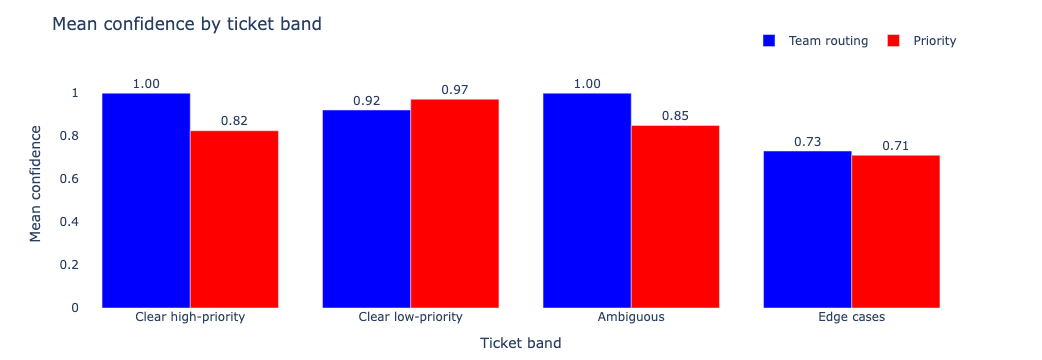

In [10]:
band_order  = ["clear_high", "clear_low", "ambiguous", "edge"]
band_labels = {
    "clear_high": "Clear high-priority",
    "clear_low":  "Clear low-priority",
    "ambiguous":  "Ambiguous",
    "edge":       "Edge cases",
}

band_summary = (
    results_df
    .groupby("band")
    .agg(
        mean_team_conf    =("team_confidence",     "mean"),
        mean_priority_conf=("priority_confidence", "mean"),
        count             =("id",                  "count"),
    )
    .reset_index()
)
band_summary["band"] = pd.Categorical(
    band_summary["band"], categories=band_order, ordered=True
)
band_summary = band_summary.sort_values("band")
band_summary["band_label"] = band_summary["band"].map(band_labels)

fig1 = go.Figure()
fig1.add_trace(go.Bar(
    name="Team routing",
    x=band_summary["band_label"],
    y=band_summary["mean_team_conf"],
    marker_color="blue",
    text=[f"{v:.2f}" for v in band_summary["mean_team_conf"]],
    textposition="outside",
))
fig1.add_trace(go.Bar(
    name="Priority",
    x=band_summary["band_label"],
    y=band_summary["mean_priority_conf"],
    marker_color="red",
    text=[f"{v:.2f}" for v in band_summary["mean_priority_conf"]],
    textposition="outside",
))
fig1.update_layout(
    title="Mean confidence by ticket band",
    xaxis_title="Ticket band",
    yaxis_title="Mean confidence",
    yaxis=dict(range=[0, 1.15]),
    barmode="group",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig1.show()

## 8. Confidence by customer tier

Does Jev's confidence vary with customer tier? Enterprise tickets tend to have more context in the description, which might produce clearer signals.

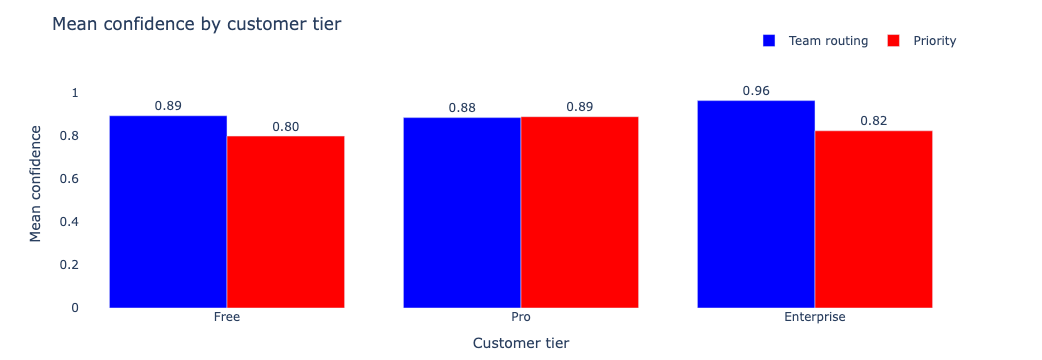

In [11]:
tier_order = ["Free", "Pro", "Enterprise"]

tier_summary = (
    results_df
    .groupby("tier")
    .agg(
        mean_team_conf     =("team_confidence",     "mean"),
        mean_priority_conf =("priority_confidence", "mean"),
        count              =("id",                  "count"),
    )
    .reset_index()
)
tier_summary["tier"] = pd.Categorical(
    tier_summary["tier"], categories=tier_order, ordered=True
)
tier_summary = tier_summary.sort_values("tier")

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    name="Team routing",
    x=tier_summary["tier"],
    y=tier_summary["mean_team_conf"],
    marker_color="blue",
    text=[f"{v:.2f}" for v in tier_summary["mean_team_conf"]],
    textposition="outside",
))
fig2.add_trace(go.Bar(
    name="Priority",
    x=tier_summary["tier"],
    y=tier_summary["mean_priority_conf"],
    marker_color="red",
    text=[f"{v:.2f}" for v in tier_summary["mean_priority_conf"]],
    textposition="outside",
))
fig2.update_layout(
    title="Mean confidence by customer tier",
    xaxis_title="Customer tier",
    yaxis_title="Mean confidence",
    yaxis=dict(range=[0, 1.15]),
    barmode="group",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig2.show()

## 9. Low-confidence tickets

Tickets where either the team or priority confidence falls below 0.60 are candidates for human review before routing. This is where the confidence score earns its place -- not just as a curiosity but as an actionable signal.

In [12]:
CONFIDENCE_THRESHOLD = 0.60

low_conf = results_df[
    (results_df["team_confidence"]     < CONFIDENCE_THRESHOLD) |
    (results_df["priority_confidence"] < CONFIDENCE_THRESHOLD)
].copy()

if low_conf.empty:
    print(f"No tickets fell below the {CONFIDENCE_THRESHOLD} threshold.")
else:
    print(f"{len(low_conf)} ticket(s) below the {CONFIDENCE_THRESHOLD} threshold:\n")
    for _, row in low_conf.iterrows():
        print(f"  {row['id']} [{row['band']}] {row['subject'][:55]}")
        print(f"    Team:     {row['team']:20} (confidence: {row['team_confidence']:.2f})")
        print(f"    Priority: {row['priority']:8} (confidence: {row['priority_confidence']:.2f})")
        print()

low_conf[display_cols]

4 ticket(s) below the 0.6 threshold:

  T002 [clear_high] Incorrect charge of $48,000 on our account
    Team:     Billing              (confidence: 0.98)
    Priority: High     (confidence: 0.57)

  T003 [clear_high] Data export completely broken since this morning
    Team:     Technical            (confidence: 1.00)
    Priority: Critical (confidence: 0.57)

  T016 [edge] Found a security bug in your login page
    Team:     Technical            (confidence: 1.00)
    Priority: High     (confidence: 0.27)

  T018 [edge] Want to upgrade but billing page is broken
    Team:     Technical            (confidence: 0.22)
    Priority: High     (confidence: 0.96)



,id,tier,band,team,team_confidence,priority,priority_confidence
1,T002,Enterprise,clear_high,Billing,0.98,High,0.57
2,T003,Pro,clear_high,Technical,1.00,Critical,0.57
15,T016,Free,edge,Technical,1.00,High,0.27
17,T018,Pro,edge,Technical,0.22,High,0.96


## 10. Routing distribution

How did Jev distribute tickets across teams and priority levels?

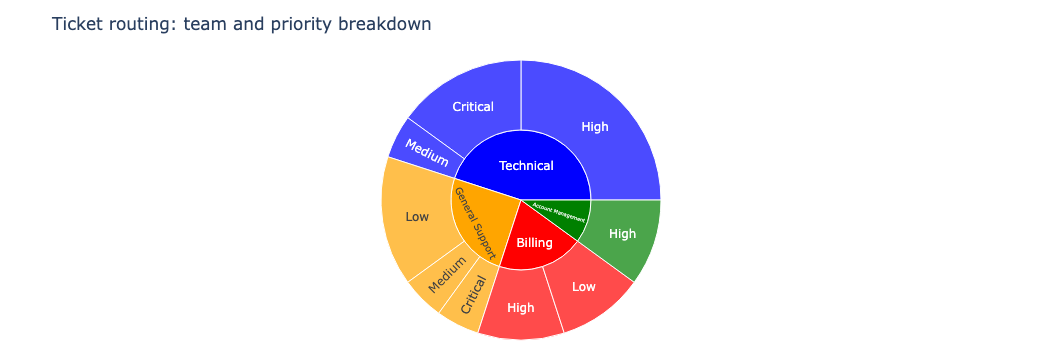

In [13]:
priority_order = ["Critical", "High", "Medium", "Low"]

fig3 = px.sunburst(
    results_df,
    path=["team", "priority"],
    color="team",
    color_discrete_map={
        "Technical":          "blue",
        "Billing":            "red",
        "Account Management": "green",
        "General Support":    "orange",
    },
    title="Ticket routing: team and priority breakdown",
)
fig3.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=20),
)
fig3.show()

## 11. Latency

Two Jev calls per ticket. Total time per ticket is the sum of both.

In [14]:
results_df["total_ms"] = results_df["team_ms"] + results_df["priority_ms"]

print(f"Team routing:  mean {results_df['team_ms'].mean():.0f}ms, "
      f"min {results_df['team_ms'].min():.0f}ms, "
      f"max {results_df['team_ms'].max():.0f}ms")
print(f"Priority:      mean {results_df['priority_ms'].mean():.0f}ms, "
      f"min {results_df['priority_ms'].min():.0f}ms, "
      f"max {results_df['priority_ms'].max():.0f}ms")
print(f"Total/ticket:  mean {results_df['total_ms'].mean():.0f}ms, "
      f"min {results_df['total_ms'].min():.0f}ms, "
      f"max {results_df['total_ms'].max():.0f}ms")

Team routing:  mean 235ms, min 194ms, max 315ms
Priority:      mean 219ms, min 194ms, max 272ms
Total/ticket:  mean 454ms, min 400ms, max 587ms


## 12. Summary

Two sequential `Choice` calls -- team then priority -- triaged 20 tickets in well under a minute. Each decision returned a calibrated confidence score alongside the routing answer, which means the system can automatically flag uncertain cases for human review rather than routing them silently.

The confidence scores told a nuanced story: team routing confidence was high across almost all bands, including ambiguous ones -- Jev generally knew where a ticket belonged even when the urgency was unclear. Priority confidence was the more variable signal and edge cases produced the lowest confidence on both decisions. The low-confidence tickets flagged above are the ones a rules-based router would have routed silently and incorrectly, or not at all.

A production implementation would set a confidence threshold -- tickets above it route automatically, tickets below it join a human review queue. The threshold itself is a business decision: a lower threshold means more human review but fewer routing errors; a higher threshold means faster routing but more misrouted tickets.